In [39]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, BatchNormalization, Activation, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Set image size


In [8]:
IMG_SIZE = 128


# Paths to dataset 


In [11]:
GRAY_IMAGE_DIR = "landscape Images/gray"
COLOR_IMAGE_DIR = "landscape Images/color"

# 🔹 Load and preprocess images


In [12]:
gray_images, color_images = [], []

for img_name in tqdm(os.listdir(GRAY_IMAGE_DIR)):
    img_path = os.path.join(GRAY_IMAGE_DIR, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: continue  
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    gray_images.append(np.expand_dims(img, axis=-1))

for img_name in tqdm(os.listdir(COLOR_IMAGE_DIR)):
    img_path = os.path.join(COLOR_IMAGE_DIR, img_name)
    img = cv2.imread(img_path)
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    color_images.append(img)


100%|██████████| 7129/7129 [02:02<00:00, 58.43it/s]


# Convert to NumPy arrays


In [13]:
gray_images = np.array(gray_images, dtype=np.float32)
color_images = np.array(color_images, dtype=np.float32)


# Split into training and testing sets


In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(gray_images, color_images, test_size=0.1, random_state=42)

print(f"Training samples: {X_train.shape}, Testing samples: {X_test.shape}")

Training samples: (6416, 128, 128, 1), Testing samples: (713, 128, 128, 1)


# 🔹 Define the CNN Model (U-Net Style)


# 🔹 Define the Generator (U-Net Style)


In [35]:
def build_model():
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    x = Conv2D(64, (3, 3), strides=2, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(128, (3, 3), strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(256, (3, 3), strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # Decoder
    x = Conv2DTranspose(128, (3, 3), strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2DTranspose(64, (3, 3), strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2DTranspose(32, (3, 3), strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    outputs = Conv2D(3, (3, 3), padding="same", activation="sigmoid")(x)

    model = Model(inputs, outputs)
    return model

# 🔹 Define the Discriminator (PatchGAN)


In [40]:
def build_discriminator():
    inputs_gray = Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    inputs_color = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    x = Concatenate()([inputs_gray, inputs_color])
    
    def disc_block(x, filters):
        x = Conv2D(filters, (3, 3), strides=2, padding="same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha=0.2)(x)
        return x
    
    x = disc_block(x, 64)
    x = disc_block(x, 128)
    x = disc_block(x, 256)
    x = disc_block(x, 512)
    
    x = Conv2D(1, (3, 3), padding="same", activation="sigmoid")(x)
    return Model([inputs_gray, inputs_color], x, name="Discriminator")

# Build models
generator = build_generator()
discriminator = build_discriminator()

generator.compile(loss="mse", optimizer=Adam(2e-4, beta_1=0.5))
discriminator.compile(loss="binary_crossentropy", optimizer=Adam(2e-4, beta_1=0.5))

generator.summary()
discriminator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │        640 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │     73,856 │ leaky_re_lu_4[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │    295,168 │ leaky_re_lu_5[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 8, 8, 512) │  1,180,160 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 16, 16,    │  1,179,904 │ leaky_re_lu_7[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ activation_7[0][… │
│ (Concatenate)       │ 512)              │            │ leaky_re_lu_6[0]

 Total params: 3,476,291 (13.26 MB)

 Trainable params: 3,473,475 (13.25 MB)

 Non-trainable params: 2,816 (11.00 KB)

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 128, 128,  │          0 │ input_layer_5[0]… │
│ (Concatenate)       │ 4)                │            │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │      2,368 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 32, 32,    │     73,856 │ leaky_re_lu_8[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 16, 16,    │    295,168 │ leaky_re_lu_9[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 8, 8, 512) │  1,180,160 │ leaky_re_lu_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 8, 8, 1)   │      4,609 │ leaky_re_lu_11[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,560,001 (5.95 MB)

 Trainable params: 1,558,081 (5.94 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [48]:
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# 🔹 Train the GAN Model


In [51]:
# Build models
generator = build_generator()
discriminator = build_discriminator()

# Compile models
generator.compile(loss="mse", optimizer=Adam(2e-4, beta_1=0.5))
discriminator.compile(loss="binary_crossentropy", optimizer=Adam(2e-4, beta_1=0.5))


In [53]:
def build_gan(generator, discriminator):
    discriminator.trainable = False  # Freeze discriminator when training GAN
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    generated_color = generator(inputs)
    validity = discriminator([inputs, generated_color])
    
    gan_model = Model(inputs, validity)
    gan_model.compile(loss="binary_crossentropy", optimizer=Adam(2e-4, beta_1=0.5))
    return gan_model

# Build GAN model
gan = build_gan(generator, discriminator)


ValueError: Input 1 of layer "Discriminator" is incompatible with the layer: expected shape=(None, 128, 128, 3), found shape=(None, 64, 64, 3)

In [52]:
EPOCHS = 50
BATCH_SIZE = 32

for epoch in range(EPOCHS):
    for i in range(len(X_train) // BATCH_SIZE):
        idx = np.random.randint(0, len(X_train), BATCH_SIZE)
        gray_batch = X_train[idx]
        color_batch = Y_train[idx]
        
        # Generate fake images
        fake_color = generator.predict(gray_batch)
        
        # Create labels for real and fake images
        real_labels = np.ones((BATCH_SIZE, 16, 16, 1))
        fake_labels = np.zeros((BATCH_SIZE, 16, 16, 1))
        
        # Train discriminator
        d_loss_real = discriminator.train_on_batch([gray_batch, color_batch], real_labels)
        d_loss_fake = discriminator.train_on_batch([gray_batch, fake_color], fake_labels)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
        
        # Train generator (to fool discriminator)
        g_loss = gan.train_on_batch(gray_batch, real_labels)
    
    print(f"Epoch {epoch+1}/{EPOCHS} - D Loss: {d_loss:.4f}, G Loss: {g_loss:.4f}")

# Save the trained generator
generator.save("colorization_gan_generator.h5")
print("GAN Model Trained & Saved!")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(32, 16, 16, 1), output.shape=(32, 8, 8, 1)

# Compile the model


In [16]:
model = build_model()
model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 760,515 (2.90 MB)

 Trainable params: 759,171 (2.90 MB)

 Non-trainable params: 1,344 (5.25 KB)

# Reduce learning rate when loss plateaus


In [17]:
reduce_lr = ReduceLROnPlateau(monitor="loss", factor=0.5, patience=3, verbose=1, min_lr=1e-6)


# 🔹 Train the Model


In [19]:
history = model.fit(X_train, Y_train, epochs=20, batch_size=32, validation_data=(X_test, Y_test), callbacks=[reduce_lr])


Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.4232 - loss: 0.0158 - val_accuracy: 0.4517 - val_loss: 0.0629 - learning_rate: 0.0010
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.4704 - loss: 0.0104 - val_accuracy: 0.4622 - val_loss: 0.0301 - learning_rate: 0.0010
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.4786 - loss: 0.0091 - val_accuracy: 0.4179 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.4806 - loss: 0.0088 - val_accuracy: 0.4207 - val_loss: 0.0100 - learning_rate: 0.0010
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.4793 - loss: 0.0083 - val_accuracy: 0.4504 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.4849 - loss: 0.0077 - val_accuracy: 0.5021 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.4856 - loss: 0.

# 🔹 Test the Model on New Images


23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step


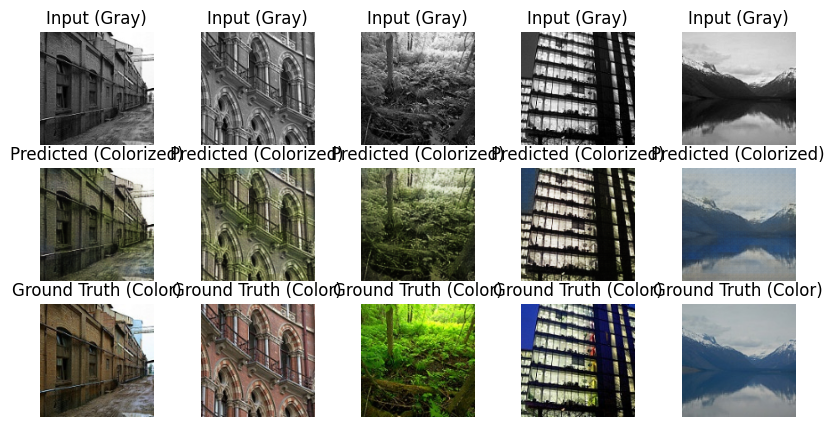

In [20]:
def test_model(model, X_test, Y_test, num_samples=5):
    predictions = model.predict(X_test)

    plt.figure(figsize=(10, 5))
    for i in range(num_samples):
        plt.subplot(3, num_samples, i + 1)
        plt.imshow(X_test[i].squeeze(), cmap="gray")
        plt.axis("off")
        plt.title("Input (Gray)")

        plt.subplot(3, num_samples, i + 1 + num_samples)
        plt.imshow(predictions[i])
        plt.axis("off")
        plt.title("Predicted (Colorized)")

        plt.subplot(3, num_samples, i + 1 + 2 * num_samples)
        plt.imshow(Y_test[i])
        plt.axis("off")
        plt.title("Ground Truth (Color)")

    plt.show()

test_model(model, X_test, Y_test)


# 🔹 Accuracy Metrics (SSIM & PSNR)


In [29]:
def calculate_metrics(model, X_test, Y_test):
    predictions = model.predict(X_test)
    total_ssim, total_psnr = 0, 0
    num_samples = len(X_test)

    for i in range(num_samples):
        pred_img = (predictions[i] * 255).astype(np.uint8)
        true_img = (Y_test[i] * 255).astype(np.uint8)

        # Ensure the images have 3 channels before converting to grayscale
        if pred_img.shape[-1] == 3:
            pred_gray = cv2.cvtColor(pred_img, cv2.COLOR_RGB2GRAY)
        else:
            pred_gray = pred_img  # Already grayscale

        if true_img.shape[-1] == 3:
            true_gray = cv2.cvtColor(true_img, cv2.COLOR_RGB2GRAY)
        else:
            true_gray = true_img  # Already grayscale

        # Compute SSIM and PSNR
        ssim_value = ssim(pred_gray, true_gray, data_range=255)
        psnr_value = psnr(true_gray, pred_gray, data_range=255)

        total_ssim += ssim_value
        total_psnr += psnr_value

    avg_ssim = total_ssim / num_samples
    avg_psnr = total_psnr / num_samples

    print(f"\n🔹 Average SSIM: {avg_ssim:.4f}")
    print(f"🔹 Average PSNR: {avg_psnr:.2f} dB")

calculate_metrics(model, X_test, Y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step

🔹 Average SSIM: 0.9525
🔹 Average PSNR: 31.88 dB


# 🔹 Save Model for Future Use


In [30]:
model.save("image_colorization_model.h5")
print("Model saved successfully!")

Model saved successfully!
